# Background-derived control modes

Fit DMD to a spectral-infill background-only record, treat its feasible recovered modes as a control suite, and evaluate their subsequent recovery using the same figures and tables as the synthetic initial tests.

## Preamble

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

cwd = Path(os.getcwd()).resolve()
PROJECT_ROOT = next(
    path for path in (cwd, *cwd.parents)
    if (path / 'src' / 'msc_thesis').is_dir()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_th

## Configuration

The selected control configuration is Hankel $d=6$, no SVD rank truncation, and $n_{\max}=9$. A feasible background mode has a finite period strictly between 3 and 100 years; no quality-factor constraint is applied.

In [3]:
chosen_nmax = 9
chosen_svd_rank = 12
chosen_embedding_d = 7
n_ensemble = 100
control_period_limits = (3, 100)
background_seed = 42

chosen_dmd_settings = {
    'dmd_type': 'exact',
    'hankel_flag': True,
    'embedding_d': chosen_embedding_d,
    'weight_flag': True,
}

## Construct the background-derived control suite

In [4]:
gnm_chaos = CHAOS_Full_SV_Record_Obtain(nmax=chosen_nmax)
gnm_background = gnm_chaos

A_control_r = Truncate_Gauss_Coeffs(A_15_r, tmax=chosen_nmax)
gnm_background_control = Truncate_Gauss_Coeffs(
    gnm_background,
    tmax=chosen_nmax,
)
background_record = A_control_r @ gnm_background_control.T

background_dmd_modes = Run_DMD(
    background_record,
    times_used_relative,
    svd_rank=chosen_svd_rank,
    dmd_settings=chosen_dmd_settings.copy(),
)
background_periods = np.asarray(background_dmd_modes['periods'], dtype=float)
period_min, period_max = control_period_limits
feasible_control_mask = (
    np.isfinite(background_periods)
    & (background_periods > period_min)
    & (background_periods < period_max)
)
feasible_control_indices = np.flatnonzero(feasible_control_mask)
feasible_control_indices = feasible_control_indices[
    np.argsort(background_periods[feasible_control_indices])
]

control_cmap = plt.get_cmap('cividis')
control_colours = control_cmap(
    np.linspace(0.10, 0.90, len(feasible_control_indices))
)
control_modes = {}
for control_number, (mode_index, mode_colour) in enumerate(
    zip(feasible_control_indices, control_colours),
    start=1,
):
    control_period = float(background_periods[mode_index])
    control_modes[f'C{control_number}'] = {
        'phasor': np.asarray(
            background_dmd_modes['phasors'][mode_index],
            dtype=complex,
        ),
        'eigenvalue': complex(
            background_dmd_modes['continuous_eigenvalues'][mode_index]
        ),
        'period': control_period,
        'true_period': control_period,
        'colour': mode_colour,
    }

print(f'Feasible control modes: {len(control_modes)}')
for control_key, control_info in control_modes.items():
    print(f"  {control_key}: {control_info['period']:.2f} years")

Feasible control modes: 6
  C1: 4.26 years
  C2: 5.75 years
  C3: 7.62 years
  C4: 13.28 years
  C5: 23.41 years
  C6: 96.01 years


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 113376.4120852725. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


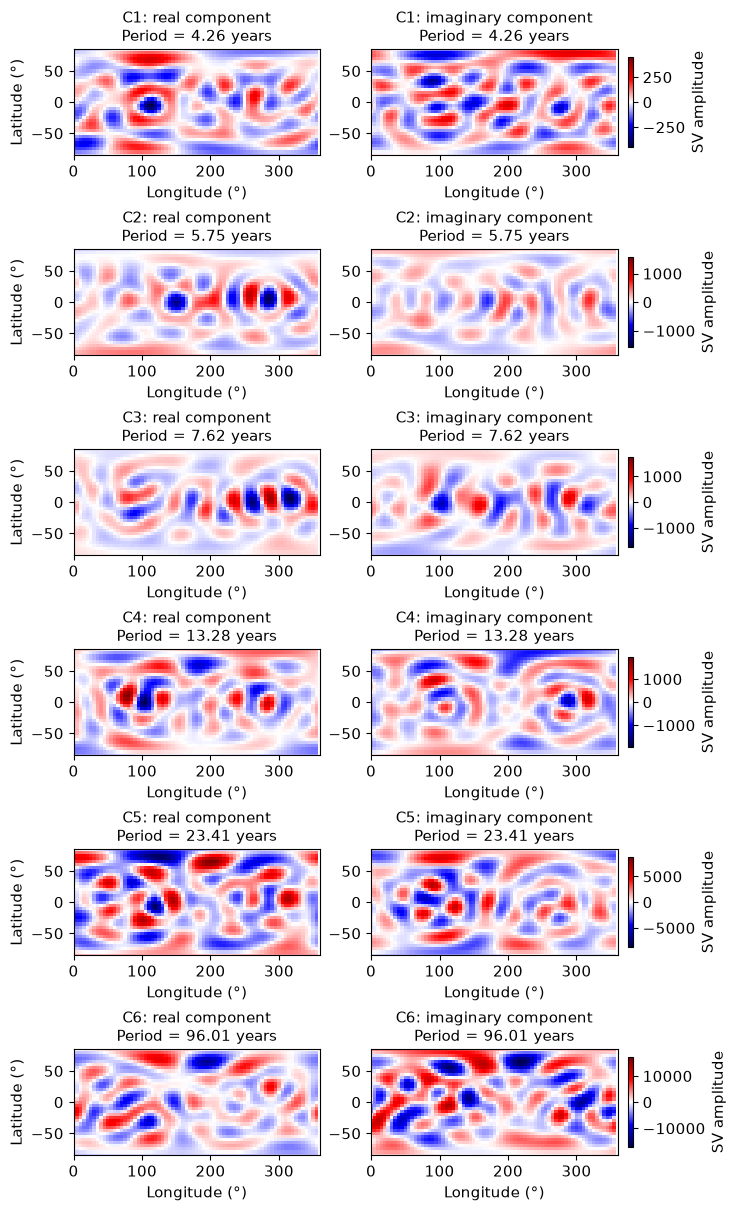

In [5]:
control_figure, control_axes = Plot_Mode_Phasors(
    control_modes,
    nmax=chosen_nmax,
    figure_width=text_width,
)
plt.show()

In [29]:
Plot_Mode_Suite_Video_Mollweide(control_modes, times_used_relative, output_path=f"{FIG_DIR}/effective_rank_variance_update_set.mp4")

Saved video to: /home/elliott/projects/msc_thesis_project/figures/effective_rank_variance_update_set.mp4


PosixPath('/home/elliott/projects/msc_thesis_project/figures/effective_rank_variance_update_set.mp4')

## Rank–degree recovery heatmap

The degree sweep stops at the selected $n_{\max}=9$. The red dashed cell identifies the chosen untruncated-rank configuration.

/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1428: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 113376.4120852725. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


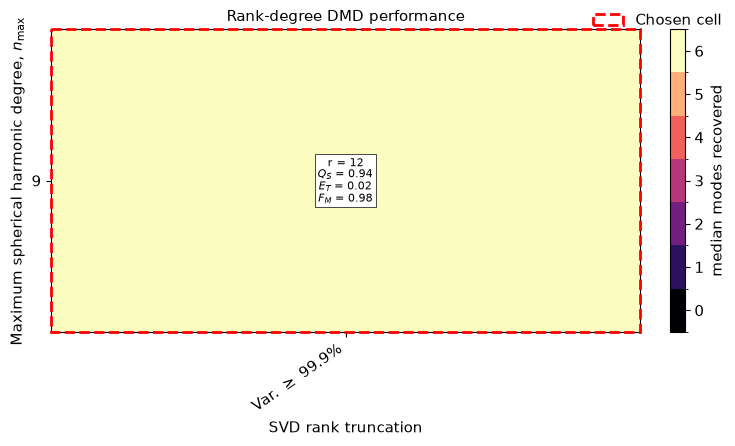

In [18]:
nmax_list = [5, 7, 9]
svd_rank_list = [
    0.9, 0.99, 0.999, 0.9999,
    -1, 2 * len(control_modes), 0,
]

nmax_list = [9]
svd_rank_list = [0.999]
heatmap_ensemble_settings = {
    'ensemble_flag': True,
    'n_ensemble': n_ensemble,
    'record_for_ensemble': 'control',
}

heatmap_figure, heatmap_axis, heatmap_colourbar = Rank_Degree_Heatmap(
    {'control': gnm_background},
    control_modes,
    nmax_list,
    svd_rank_list,
    chosen_dmd_settings.copy(),
    heatmap_ensemble_settings,
    syn_record=False,
    chosen_rank_degree=(chosen_svd_rank, chosen_nmax),
)

## Chosen control recovery and uncertainty ensemble

In [5]:
chosen_svd_rank = 0.999

chosen_ensemble_settings = {
    'ensemble_flag': True,
    'n_ensemble': n_ensemble,
    'record_for_ensemble': 'control',
}

chosen_dmd_settings = {
    'dmd_type': 'exact',
    'hankel_flag': False,
    'embedding_d': chosen_embedding_d,
    'weight_flag': True,
}
control_results, total_unmatched_periods, recovered_control_modes = (
    Pipeline_Run(
        {'control': gnm_background},
        control_modes,
        chosen_dmd_settings.copy(),
        nmax=chosen_nmax,
        svd_rank=chosen_svd_rank,
        ensemble_settings=chosen_ensemble_settings,
        syn_record=False,
        total_unmatched_period_return=True,
    )
)
control_results = Ensemble_To_Median(control_results, control_modes)
control_similarity_threshold = similarity_thresholds[
    'full_match'
][str(chosen_nmax)]

/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:641: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:1428: RuntimeWarning: divide by zero encountered in scalar divide
  period = 2.0 * np.pi / np.abs(eig.imag)
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 281030.0531335437. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


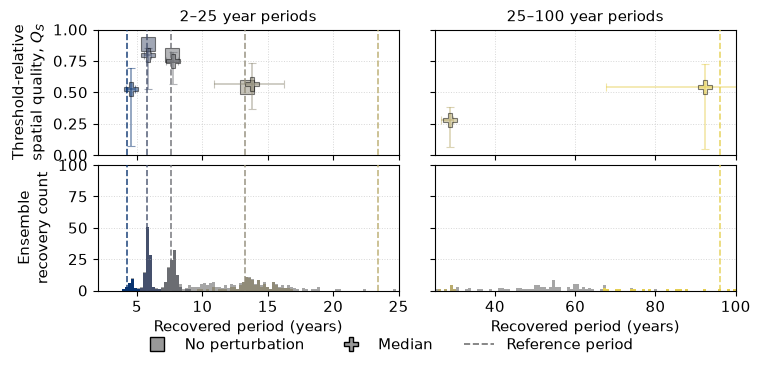

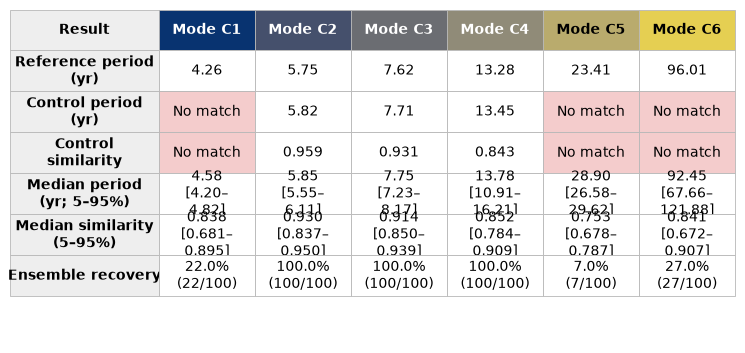

In [6]:
recovery_figure, recovery_axes = Plot_Single_Run_Ensemble_Results(
    control_results,
    control_modes,
    total_unmatched_periods,
    control_similarity_threshold,
    record_markers,
    record_plotting_params,
    figure_width=text_width,
    non_perturbed_record='control',
)
plt.savefig(f"{RESULT_DIR}/chaos_results_d7_no_hankel.png", dpi=300, bbox_inches="tight")

summary_figure, summary_table = Single_Run_Ensemble_Results_Table(
    control_results,
    control_modes,
    non_perturbed_record='control',
    ensemble_percentage_basis='attempted',
    figure_width=text_width,
)

plt.savefig(f"{RESULT_DIR}/chaos_results_d7_table_no_hankel.png", dpi=300, bbox_inches="tight")

plt.show()

In [21]:
extra_dmd_settings = {
    'dmd_type': 'exact',
    'hankel_flag': False,
    'embedding_d': 1,
    'weight_flag': True,
}

chosen_ensemble_settings = {
    'ensemble_flag': True,
    'n_ensemble': n_ensemble,
    'record_for_ensemble': 'control',
}
control_results, total_unmatched_periods, recovered_control_modes = (
    Pipeline_Run(
        {'control': gnm_background},
        control_modes,
        extra_dmd_settings.copy(),
        nmax=chosen_nmax,
        svd_rank=0.999,
        ensemble_settings=chosen_ensemble_settings,
        syn_record=False,
        total_unmatched_period_return=True,
    )
)
control_results = Ensemble_To_Median(control_results, control_modes)
control_similarity_threshold = similarity_thresholds[
    'full_match'
][str(chosen_nmax)]

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 281030.0531335437. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


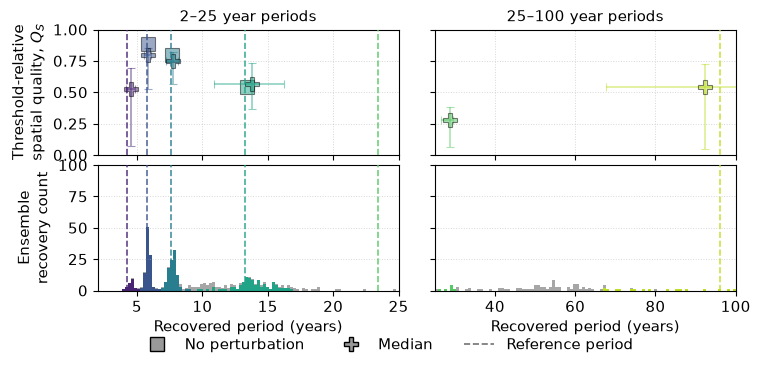

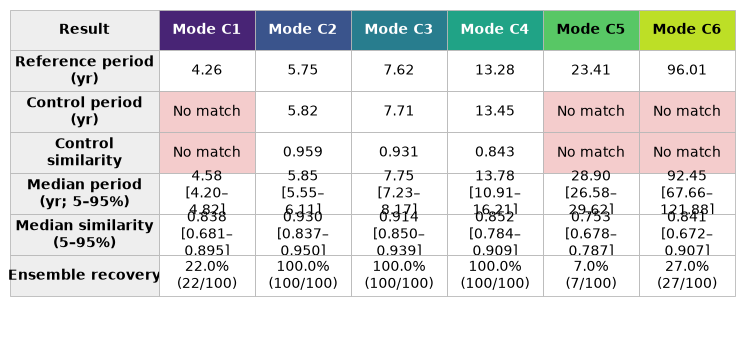

In [23]:
recovery_figure, recovery_axes = Plot_Single_Run_Ensemble_Results(
    control_results,
    control_modes,
    total_unmatched_periods,
    control_similarity_threshold,
    record_markers,
    record_plotting_params,
    figure_width=text_width,
    non_perturbed_record='control',
)
plt.savefig(f"{RESULT_DIR}/chaos_results_no_hankel.png", dpi=300, bbox_inches="tight")


summary_figure, summary_table = Single_Run_Ensemble_Results_Table(
    control_results,
    control_modes,
    non_perturbed_record='control',
    ensemble_percentage_basis='attempted',
    figure_width=text_width,
)
plt.savefig(f"{RESULT_DIR}/chaos_results_no_hankel_table.png", dpi=300, bbox_inches="tight")


plt.show()